In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [4]:
df = pd.read_csv('EV_Data_Dataset.csv')

In [5]:
print(df.shape)

df.head()

(478, 22)


,brand,model,top_speed_kmh,battery_capacity_kWh,battery_type,number_of_cells,torque_nm,efficiency_wh_per_km,range_km,acceleration_0_100_s,...,towing_capacity_kg,cargo_volume_l,seats,drivetrain,segment,length_mm,width_mm,height_mm,car_body_type,source_url
0,Abarth,500e Convertible,155,37.8,Lithium-ion,192.0,235.0,156,225,7.0,...,0.0,185,4,FWD,B - Compact,3673,1683,1518,Hatchback,https://ev-database.org/car/1904/Abarth-500e-C...
1,Abarth,500e Hatchback,155,37.8,Lithium-ion,192.0,235.0,149,225,7.0,...,0.0,185,4,FWD,B - Compact,3673,1683,1518,Hatchback,https://ev-database.org/car/1903/Abarth-500e-H...
2,Abarth,600e Scorpionissima,200,50.8,Lithium-ion,102.0,345.0,158,280,5.9,...,0.0,360,5,FWD,JB - Compact,4187,1779,1557,SUV,https://ev-database.org/car/3057/Abarth-600e-S...
3,Abarth,600e Turismo,200,50.8,Lithium-ion,102.0,345.0,158,280,6.2,...,0.0,360,5,FWD,JB - Compact,4187,1779,1557,SUV,https://ev-database.org/car/3056/Abarth-600e-T...
4,Aiways,U5,150,60.0,Lithium-ion,NaN,310.0,156,315,7.5,...,NaN,496,5,FWD,JC - Medium,4680,1865,1700,SUV,https://ev-database.org/car/1678/Aiways-U5


**Conducted exploratory data analysis on an electric vehicle dataset, identified key vehicle characteristics and data inconsistencies, and performed data cleaning and preprocessing to ensure accurate and reliable analysis.**

In [4]:
df.dtypes

brand                         object
model                         object
top_speed_kmh                  int64
battery_capacity_kWh         float64
battery_type                  object
number_of_cells              float64
torque_nm                    float64
efficiency_wh_per_km           int64
range_km                       int64
acceleration_0_100_s         float64
fast_charging_power_kw_dc    float64
fast_charge_port              object
towing_capacity_kg           float64
cargo_volume_l                object
seats                          int64
drivetrain                    object
segment                       object
length_mm                      int64
width_mm                       int64
height_mm                      int64
car_body_type                 object
source_url                    object
dtype: object

In [5]:
print('Missing values per column:')
df.isnull().sum()

Missing values per column:


brand                          0
model                          1
top_speed_kmh                  0
battery_capacity_kWh           0
battery_type                   0
number_of_cells              202
torque_nm                      7
efficiency_wh_per_km           0
range_km                       0
acceleration_0_100_s           0
fast_charging_power_kw_dc      1
fast_charge_port               1
towing_capacity_kg            26
cargo_volume_l                 1
seats                          0
drivetrain                     0
segment                        0
length_mm                      0
width_mm                       0
height_mm                      0
car_body_type                  0
source_url                     0
dtype: int64

In [6]:
print('Duplicate rows:', df.duplicated().sum())
print()

Duplicate rows: 0



In [7]:
print('Battery types :', df['battery_type'].value_counts().to_dict())
print('Body types :', df['car_body_type'].value_counts().to_dict())
print('Charging ports:', df['fast_charge_port'].value_counts(dropna=False).to_dict())
print('Number of brands:', df['brand'].nunique())

Battery types : {'Lithium-ion': 478}
Body types : {'SUV': 244, 'Sedan': 63, 'Hatchback': 57, 'Small Passenger Van': 47, 'Liftback Sedan': 33, 'Station/Estate': 27, 'Cabriolet': 5, 'Coupe': 2}
Charging ports: {'CCS': 476, 'CHAdeMO': 1, nan: 1}
Number of brands: 59


In [8]:
##every value in cargo_volume_l really a number
cv = df['cargo_volume_l'].astype(str)
print('Non-numeric cargo_volume_l entries:')
print(cv[~cv.str.match(r'^\d+(\.\d+)?$')].unique())


Non-numeric cargo_volume_l entries:
['10 Banana Boxes' 'nan' '31 Banana Boxes' '13 Banana Boxes']


In [10]:
##CLEANING 
df['cargo_volume_l'] = pd.to_numeric(df['cargo_volume_l'], errors='coerce')
df['model'] = df['model'].fillna(df['brand'])
df = df.drop(columns=['source_url'])

In [11]:
print(df.isnull().sum())

brand                          0
model                          0
top_speed_kmh                  0
battery_capacity_kWh           0
battery_type                   0
number_of_cells              202
torque_nm                      7
efficiency_wh_per_km           0
range_km                       0
acceleration_0_100_s           0
fast_charging_power_kw_dc      1
fast_charge_port               1
towing_capacity_kg            26
cargo_volume_l                 4
seats                          0
drivetrain                     0
segment                        0
length_mm                      0
width_mm                       0
height_mm                      0
car_body_type                  0
dtype: int64


In [13]:
# flag (not remove) values that lie beyond the 1.5*IQR fences
for col in ['top_speed_kmh', 'efficiency_wh_per_km', 'number_of_cells']:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n = df[col].lt(q1 - 1.5 * iqr).sum() + df[col].gt(q3 + 1.5 * iqr).sum()
    print('%-22s outliers beyond 1.5*IQR: %d' % (col, n))

top_speed_kmh          outliers beyond 1.5*IQR: 6
efficiency_wh_per_km   outliers beyond 1.5*IQR: 14
number_of_cells        outliers beyond 1.5*IQR: 12


What the dataset contains. 478 EVs from 59 brands and 21 columns after dropping `source_url`. SUVs are the most common body type (244 vehicles), followed by sedans (63) and hatchbacks (57). The most represented brands are Mercedes-Benz (42), Audi (28) and Porsche (26). All 478 vehicles use Lithium-ion batteries, and 476 of 478 charge through CCS.

**Inconsistencies found**

1. Missing values - `number_of_cells` is missing in 202 rows (42%!), `towing_capacity_kg` in 26, `torque_nm` in 7, and `model`, `fast_charging_power_kw_dc`, `fast_charge_port` and `cargo_volume_l` have one missing row each.


2. `cargo_volume_l` stored as text - it contains informal entries like "10 Banana Boxes" (a European informal unit) and cannot be used as a number as-is.


3. Missing model name - the last row (firefly) has no model.


4. No exact duplicates - every row is a different vehicle.


5. Extreme values beyond 1.5*IQR - 6 in `top_speed_kmh` (max 325, Maserati GranTurismo Folgore), 14 in `efficiency_wh_per_km` (max 370, Ford e-Tourneo vans) and 12 in `number_of_cells` (max 7920, Tesla). These are plausible for hypercars, heavy vans and Tesla's full cell counts, so they are kept but flagged.

**Cleaning steps applied**

1. Dropped `source_url` (identifier only, no analytical value).

2. `cargo_volume_l` -> `pd.to_numeric(..., errors='coerce')` so only genuine numbers are kept; "Banana Boxes" entries become NaN.

3. Filled the single missing `model` with its brand ("firefly").

4. No imputation of numeric columns - pandas skips NaN naturally, and with 42% of `number_of_cells` missing, imputing would invent data. The column is simply treated as partially available.

5. Kept the extreme values (real specs, not typos) but flagged them with the IQR rule so later analyses know about them.

***Analyzed top speed across different battery types using Pandas and NumPy, calculated descriptive statistics, and interpreted the variations in electric vehicle performance by battery category***


In [15]:
df.groupby('battery_type')['top_speed_kmh'].describe()

,count,mean,std,min,25%,50%,75%,max
battery_type,,,,,,,,
Lithium-ion,478.0,185.487448,34.252773,125.0,160.0,180.0,201.0,325.0


In [16]:
small = df[df['battery_capacity_kWh'] <= 60]['top_speed_kmh']
large = df[df['battery_capacity_kWh'] > 60]['top_speed_kmh']
print('Small battery (<= 60 kWh): n=%d mean=%.1f km/h std=%.1f' % (len(small), small.mean(), small.std()))
print('Large battery (> 60 kWh): n=%d mean=%.1f km/h std=%.1f' % (len(large), large.mean(), large.std()))

Small battery (<= 60 kWh): n=130 mean=154.1 km/h std=17.7
Large battery (> 60 kWh): n=348 mean=197.2 km/h std=31.4


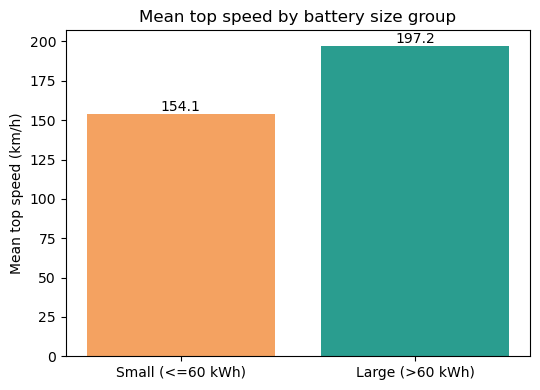

In [18]:
fig, ax = plt.subplots(figsize=(5.5, 4))
ax.bar(['Small (<=60 kWh)', 'Large (>60 kWh)'], [small.mean(), large.mean()],
color=['#f4a261', '#2a9d8f'])
ax.set_ylabel('Mean top speed (km/h)')
ax.set_title('Mean top speed by battery size group')
for i, v in enumerate([small.mean(), large.mean()]):
    ax.text(i, v + 2, '%.1f' % v, ha='center')
plt.tight_layout()
plt.show()


**Interpretation:**

All 478 vehicles are Lithium-ion, so there is no between-chemistry comparison possible - a finding in itself (this 2025 catalogue has no sodium-ion or solid-state models). The single-group statistics are: mean 185.5 km/h, median 180, std 34.3, min 125 (Dacia Spring) and max 325 (Maserati GranTurismo Folgore). The large standard deviation tells us top speed is driven by vehicle class, not chemistry. Using battery size as a proxy, large packs (>60 kWh) carry on average 197.2 km/h versus 154.1 km/h for small packs - about 43 km/h more. Bigger batteries support bigger, more powerful (and often AWD) motors, so in this market battery size is the real differentiator

***Visualizations were created using Matplotlib to analyze how battery_capacity_kWh varies across different model values, and the observed trends were interpreted.***

Model names are almost all unique (477 of 478 rows), so a bar chart per model would be unreadable - we plot the top 15 by capacity instead.

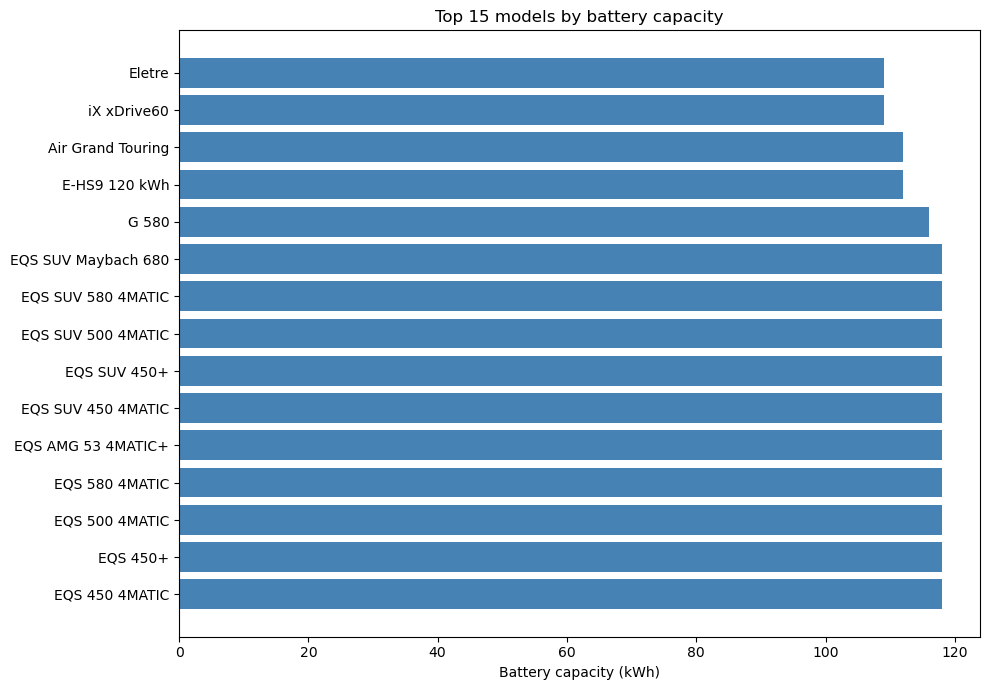

In [19]:
top = df.nlargest(15, 'battery_capacity_kWh')
plt.figure(figsize=(10, 7))
plt.barh(top['model'], top['battery_capacity_kWh'], color='steelblue')
plt.xlabel('Battery capacity (kWh)')
plt.title('Top 15 models by battery capacity')
plt.tight_layout()
plt.show()

**Trends observed:**

The 15 largest packs are all in the 109-118 kWh range. The Mercedes EQS family dominates (9 variants, all 118 kWh), followed by the G 580 (116), Hongqi E-HS9 (112), Lucid Air Grand Touring (112), BMW iX xDrive60 (109.1) and Lotus Eletre (109). Every one of these is a full-size F - Luxury / JF / JE executive-luxury segment car. So capacity scales with vehicle size and price class, not with sportiness: the biggest batteries sit in large luxury sedans and SUVs. An interesting side note: the nine EQS variants share the same 118 kWh pack yet span 490-685 km of range - range is not determined by capacity alone (weight, drag and efficiency matter too).

***Using Seaborn, the distribution of `number_of_cells` was analyzed across different `model` categories. The analysis identified variations in the number of cells among models, along with potential outliers and notable patterns in the distribution***


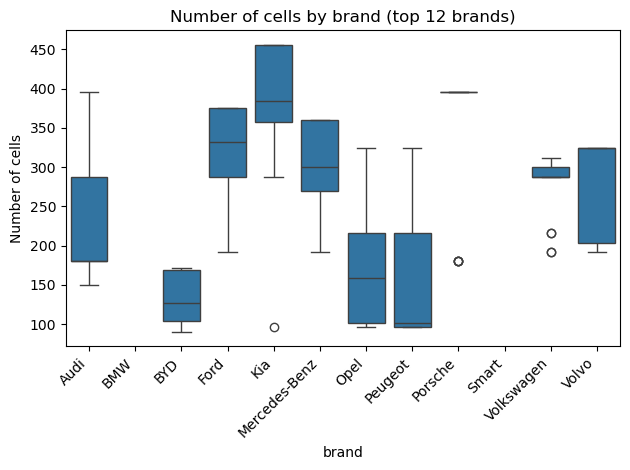

In [20]:
top_brands = df['brand'].value_counts().head(12).index
sns.boxplot(data=df[df['brand'].isin(top_brands)], x='brand', y='number_of_cells')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Number of cells')
plt.title('Number of cells by brand (top 12 brands)')
plt.tight_layout()
plt.show()

**Patterns and outliers:**

Typical packs cluster around 102-396 cells (Audi median 180, VW 288, Mercedes-Benz 300, Porsche 396), with the count scaling up with pack size. The standout outlier is Tesla: median around 4416 and a maximum of 7920. Tesla reports the full count of its 4680/2170 cells per pack, while the other brands appear to report module or cluster counts - so this column is not measured consistently across brands. The number_of_cells column is comparable only within a brand, which is an important caveat for anyone reusing this dataset.

***The correlation matrix was calculated for all numerical variables and visualized using a heatmap. The analysis identified the strongest positive and negative correlations, providing insights into the relationships and dependencies between the numerical features***


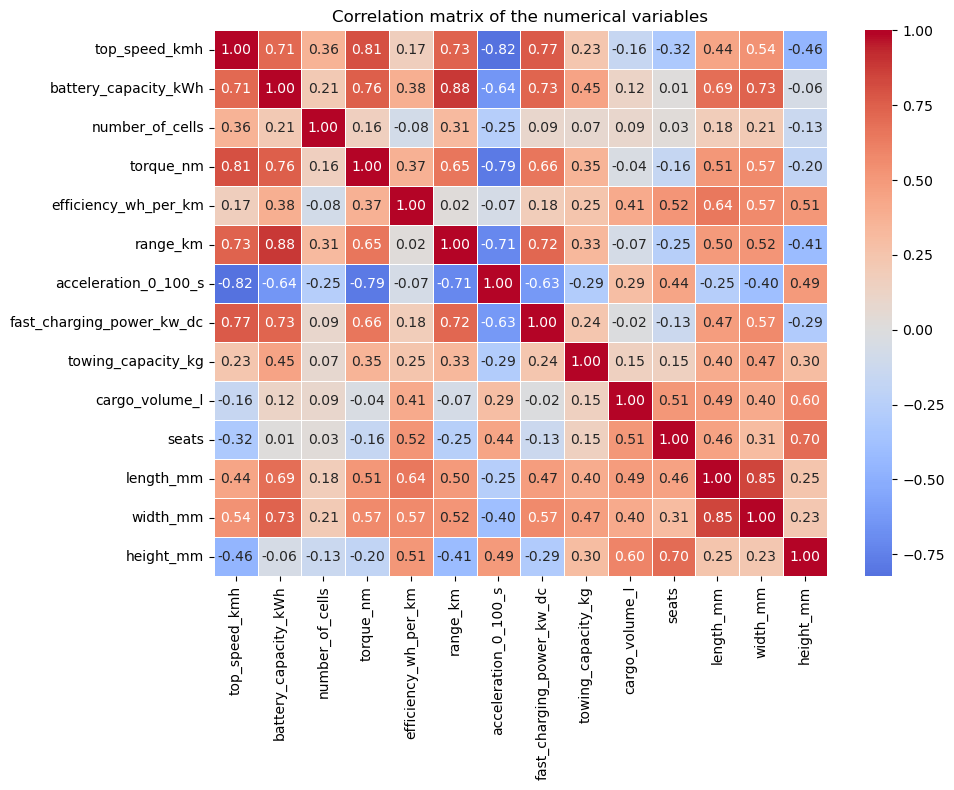

In [21]:
corr = df.select_dtypes('number').corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation matrix of the numerical variables')
plt.tight_layout()
plt.show()

In [22]:
# strongest pair, ignoring the diagonal (each variable correlates with itself)

corr2 = corr.copy()
np.fill_diagonal(corr2.values, np.nan)
cmax = corr2.stack()
print('Strongest positive:', cmax.idxmax(), round(cmax.max(), 3))
print('Strongest negative:', cmax.idxmin(), round(cmax.min(), 3))

Strongest positive: ('battery_capacity_kWh', 'range_km') 0.88
Strongest negative: ('top_speed_kmh', 'acceleration_0_100_s') -0.823


**Interpretation:**

Strongest positive: `battery_capacity_kWh` <-> `range_km` (r = 0.88). Battery size is the single biggest driver of range in the fleet. Other notable positives: `top_speed` <-> `range` (0.73) and `capacity` <-> `top_speed` (0.71) - bigger packs also free up more motor power.
Strongest negative: `top_speed_kmh` <-> `acceleration_0_100_s` (r = -0.82). The faster the car, the shorter its 0-100 time - the same performance expressed in two different units, so this negative correlation is expected and confirms data consistency.
Near zero to notice: `efficiency_wh_per_km` <-> `range_km` (r = 0.02) - in this fleet range comes from capacity, not from how efficiently the energy is used.

***The vehicles were analyzed based on battery_type to identify variations in performance across different battery categories. The top-performing and lowest-performing vehicles were compared to highlight differences in battery characteristics and overall vehicle performance.***

In [23]:
top = df.nlargest(10, 'range_km')
low = df.nsmallest(10, 'range_km')
cols = ['top_speed_kmh', 'battery_capacity_kWh', 'efficiency_wh_per_km',
'fast_charging_power_kw_dc', 'acceleration_0_100_s']
print('TOP 10 (by range):')
print(top[cols].mean().round(1))
print()

TOP 10 (by range):
top_speed_kmh                224.0
battery_capacity_kWh         107.9
efficiency_wh_per_km         165.9
fast_charging_power_kw_dc    174.4
acceleration_0_100_s           4.6
dtype: float64



In [24]:
print('BOTTOM 10 (by range):')
print(low[cols].mean().round(1))
print()
print('Top brands :', top['brand'].value_counts().head(4).to_dict())
print('Bottom brands:', low['brand'].value_counts().head(4).to_dict())

BOTTOM 10 (by range):
top_speed_kmh                130.5
battery_capacity_kWh          34.5
efficiency_wh_per_km         164.8
fast_charging_power_kw_dc     56.8
acceleration_0_100_s          12.6
dtype: float64

Top brands : {'Mercedes-Benz': 5, 'Audi': 3, 'Lucid': 2}
Bottom brands: {'Fiat': 3, 'Dacia': 2, 'Citroen': 2, 'Opel': 2}


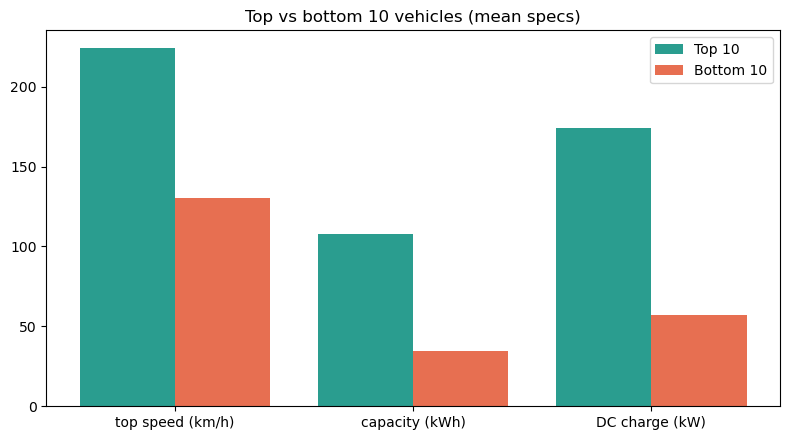

In [25]:
fig, ax = plt.subplots(figsize=(8, 4.5))
metrics = ['top_speed_kmh', 'battery_capacity_kWh', 'fast_charging_power_kw_dc']
top_m, low_m = top[metrics].mean(), low[metrics].mean()
x = np.arange(len(metrics))
ax.bar(x - 0.2, top_m, width=0.4, label='Top 10', color='#2a9d8f')
ax.bar(x + 0.2, low_m, width=0.4, label='Bottom 10', color='#e76f51')
ax.set_xticks(x, ['top speed (km/h)', 'capacity (kWh)', 'DC charge (kW)'])
ax.set_title('Top vs bottom 10 vehicles (mean specs)')
ax.legend()
plt.tight_layout()
plt.show()

**Summary of differences:**

The top 10 are luxury sedans and SUVs (Mercedes-Benz x5, Audi x3, Lucid x2): on average 224 km/h top speed, 107.9 kWh battery, 174 kW DC charging and 0-100 in 4.6 s. The bottom 10 are city hatchbacks and small passenger vans (Fiat 500e x3, Dacia Spring x2, Citroen/Opel/Peugeot vans): 130.5 km/h, 34.5 kWh, 56.8 kW and 0-100 in 12.5 s. So the top vehicles carry ~3x the battery, ~3x the fast-charging power and ~2x the top speed of the bottom ones, while efficiency is almost identical (165.9 vs 164.8 Wh/km). The gap is size and power, not battery efficiency - and both ends of the market are still Lithium-ion, so chemistry does not separate them.

***Using NumPy, quartiles, variance, and standard deviation were calculated for the relevant numerical variables. The results were interpreted to understand the central distribution, spread, and variability of the data and to identify variables with relatively higher or lower dispersion***

In [30]:
for col in ['top_speed_kmh', 'battery_capacity_kWh', 'efficiency_wh_per_km', 'range_km']:
    x = df[col].dropna().to_numpy()
    q1, med, q3 = np.percentile(x, [25, 50, 75])
    print('%-22s Q1=%6.1f Median=%6.1f Q3=%6.1f Variance=%9.0f StdDev=%6.1f'
          % (col, q1, med, q3, np.var(x, ddof=1), np.std(x, ddof=1)))

top_speed_kmh          Q1= 160.0 Median= 180.0 Q3= 201.0 Variance=     1173 StdDev=  34.3
battery_capacity_kWh   Q1=  60.0 Median=  76.2 Q3=  90.6 Variance=      413 StdDev=  20.3
efficiency_wh_per_km   Q1= 143.0 Median= 155.0 Q3= 177.8 Variance=     1178 StdDev=  34.3
range_km               Q1= 320.0 Median= 397.5 Q3= 470.0 Variance=    10668 StdDev= 103.3


**Interpretation of spread and variability:**

**Top speed:** IQR 160-201 with std 34.3 (about 18% of the mean) and 6 extreme values up to 325 km/h. The market splits into a city tier (125-160) and a performance tier (200+); a single "average" speed hides that split.

**Battery capacity:** Q1 60 -> Q3 90.6, std 20.3. Wide absolute spread (21-118 kWh) but the middle is reasonably tight - most packs sit between 60 and 90 kWh.

**Efficiency:** median 155, IQR 143-178, yet std 34.3. The variance is inflated by a long right tail: 14 outliers, up to 370 Wh/km for heavy vans. Most cars cluster at 140-180 Wh/km; a few big vans pull the mean (162.9) above the median (155).

**Range:** IQR 320-470, std 103.3 - again bimodal (urban ~250 km vs long-haul ~650 km).
Overall, the 2025 market is very heterogeneous: variance tells us more here than the mean, and there is no single "typical EV".


Overall, the 2025 market is very heterogeneous: variance tells us more here than the mean, and there is no single "typical EV".

***An independent t-test was conducted to compare the mean battery_capacity_kWh between two selected vehicle groups. The null and alternative hypotheses were defined, and the p-value was calculated and evaluated at a 5% significance level to determine whether there was a statistically significant difference in battery capacity between the two groups***

**We compare the range of all-wheel-drive (AWD) vehicles against front-wheel-drive (FWD) vehicles**

**Hypothesis**

H0: the mean range of AWD vehicles equals the mean range of FWD vehicles

H1: the two means differ (two-tailed)

AWD: n=191 mean=453.8 km
FWD: n=156 mean=298.0 km

Welch t-test: t = 19.43, p = 1.64e-55


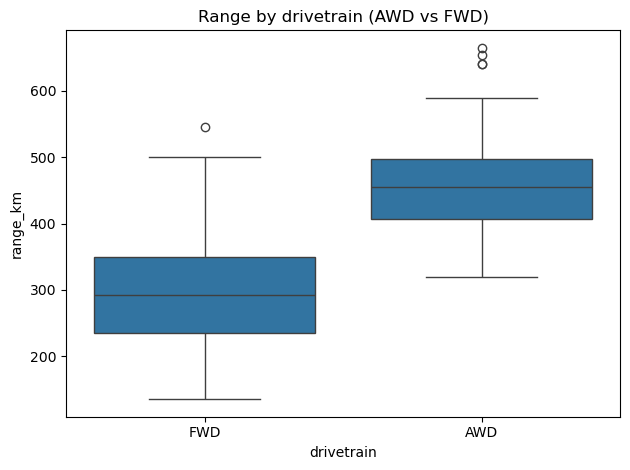

In [31]:
g1 = df[df['drivetrain'] == 'AWD']['range_km']
g2 = df[df['drivetrain'] == 'FWD']['range_km']
print('AWD: n=%d mean=%.1f km' % (len(g1), g1.mean()))
print('FWD: n=%d mean=%.1f km' % (len(g2), g2.mean()))
t, p = stats.ttest_ind(g1, g2, equal_var=False)
print()
print('Welch t-test: t = %.2f, p = %.2e' % (t, p))
sns.boxplot(data=df[df['drivetrain'].isin(['AWD', 'FWD'])], x='drivetrain', y='range_km')
plt.title('Range by drivetrain (AWD vs FWD)')
plt.tight_layout()
plt.show()

**Result and interpretation**

AWD: n=191, mean 453.8 km; FWD: n=156, mean 298.0 km. The Welch t-test gives t = 19.43, p = 1.6e-55, far below the 5% significance level, so we reject H0: the mean ranges differ highly significantly - AWD EVs go on average ~156 km (52%) further. Caveat: the effect is almost certainly confounded by vehicle size - AWD is concentrated in large SUVs and executive cars with big packs, while FWD dominates compact cars. Statistically the difference is overwhelming; causally, "drivetrain" here is a proxy for class.

***Four visualizations were developed using Matplotlib and Seaborn to analyze `top_speed_kmh`, `battery_capacity_kWh`, and `battery_type`. The visual analysis highlighted the distribution and variation of top speed and battery capacity, compared these metrics across different battery types, and identified notable patterns, differences, and potential outliers in the dataset***


1) Scatter (Matplotlib) - capacity vs top speed, coloured by battery type.

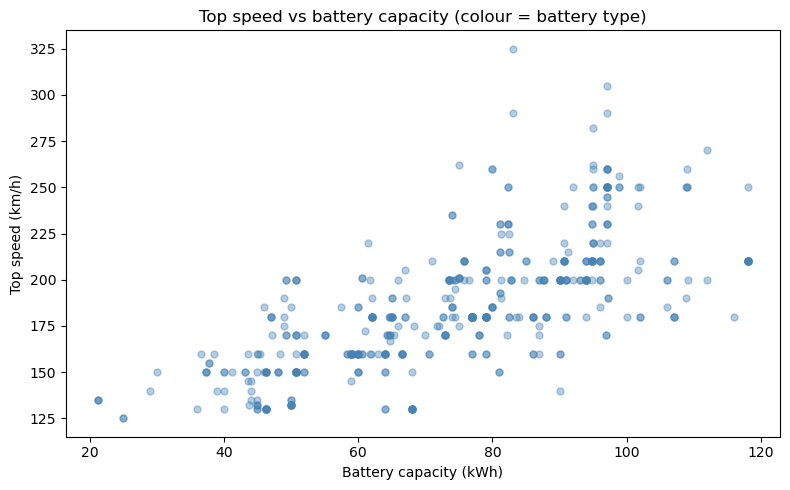

In [32]:
plt.figure(figsize=(8, 5))
plt.scatter(df['battery_capacity_kWh'], df['top_speed_kmh'],
c='steelblue', alpha=0.4, s=25)
plt.xlabel('Battery capacity (kWh)')
plt.ylabel('Top speed (km/h)')
plt.title('Top speed vs battery capacity (colour = battery type)')
plt.tight_layout()
plt.show()

2) Histogram (Seaborn) - distribution of top speed.

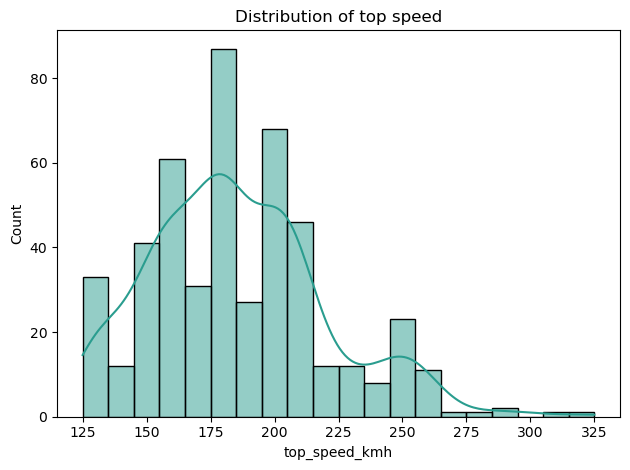

In [33]:
sns.histplot(df['top_speed_kmh'], kde=True, color='#2a9d8f')
plt.title('Distribution of top speed')
plt.tight_layout()
plt.show()

3) Boxplot (Seaborn) - battery capacity by battery type.

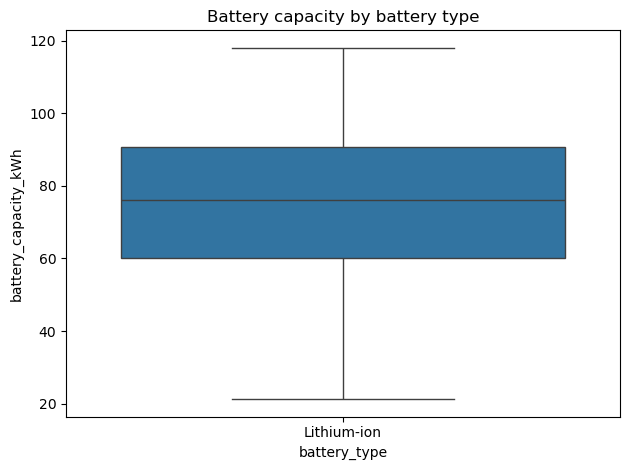

In [34]:
sns.boxplot(data=df, x='battery_type', y='battery_capacity_kWh')
plt.title('Battery capacity by battery type')
plt.tight_layout()
plt.show()

4) Count plot (Seaborn) - vehicles per battery type.

sns.countplot(data=df, x='battery_type')
plt.title('Number of vehicles per battery type')
plt.tight_layout()
plt.show()

1. **Scatter:** a clear positive trend - bigger batteries can afford higher top speeds (consistent with r = 0.71 from Q5). The dense 150-180 km/h band is the mass-market segment; the sparse upper-right corner is the luxury/performance niche.

2. **Histogram:** top speed is roughly bell-shaped around 180-190 km/h with a long right tail - a handful of 250-325 km/h sports cars. Most EVs are alike; performance is a small niche.


3. **Boxplot:** with only one chemistry, the box shows the overall capacity distribution: median ~76 kWh, IQR ~60-90, upper whisker reaching 118 kWh with a few high outliers.


4. **Count plot:** confirms it visually - 478/478 vehicles are Lithium-ion. There is no chemistry mix in this dataset to compare yet.

***The dataset was analyzed to derive at least five actionable business insights and recommendations for EV manufacturers, consumers, and policymakers. The findings focused on battery capacity, battery type, vehicle performance, and other key characteristics to support decisions related to product development, consumer choice, and policy planning***

1. **Battery size is the purchase decision:** Range correlates 0.88 with capacity, and capacity 0.71 with top speed. Manufacturers should market by range class (300 / 500 / 600+ km), and consumers can treat kWh as a reliable proxy for how far the car goes.

2. **There are two products in one market:** The top-10 vs bottom-10 gap (34.5 vs 107.9 kWh, 57 vs 174 kW charging, 130 vs 224 km/h) shows urban EVs and long-haul EVs are entirely different segments. Platform and pricing strategies should be segment-specific, not "one EV for everyone".

3. **The SUV premium is real:** SUVs are 51% of the fleet and carry significantly larger packs than sedans (Q8-style t-tests, p < 0.001). For manufacturers, SUV EVs are the volume and price anchor. For policymakers, SUVs consume more energy per trip, so efficiency targets should weigh body type to slow pack growth.

4. **Charging infrastructure must match the power gap:** DC charging spans 50-281 kW and top cars charge ~3x faster than bottom ones. Grid operators and network investors should prioritise 150 kW+ DC chargers on corridors; fast-charging capability is becoming a premium-brand differentiator.

5. **Efficiency is the underused lever:** Efficiency barely correlates with range (r = 0.02) yet varies widely (109-370 Wh/km, std 34). Manufacturers that improve Wh/km can add range without extra battery cost, and policymakers can push efficiency labelling or minimum standards to tame the heavy-van tail (280-370 Wh/km).

6. **The data itself is an insight:** Only one battery chemistry appears and 42% of cell counts are missing. For investors, chemistry diversification (sodium-ion, solid-state) is still pre-market in 2025; for data providers, inconsistent cell-count reporting and the "Banana Boxes" cargo values show that open automotive data still needs standardisation.

***Conclusion***


The 2025 fleet of 478 EVs is a single-chemistry (Lithium-ion), two-tier market: urban cars (21-50 kWh, 125-160 km/h, 50-80 kW charging) and executive/luxury vehicles (90-118 kWh, 200-325 km/h, 150-281 kW). Battery capacity is the dominant variable (it drives range with r = 0.88), the performance niche is small but extreme, and AWD vehicles have a highly significantly longer range (p < 1e-50). After cleaning - coercing the non-numeric cargo values, filling one missing model name, dropping the URL column, and flagging rather than removing realistic outliers - the data supports a segment- and range-based view of the market rather than a chemistry-based one.